# Assignment 2

![Assignment 2](assets/assn2.png)

In [107]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

import cv2
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Original Image')

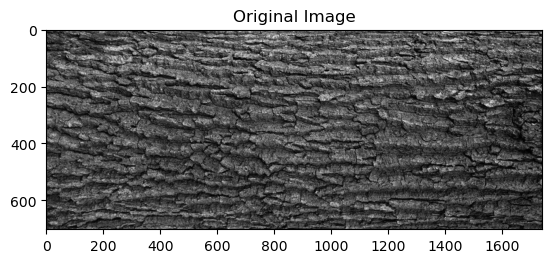

In [108]:
img = cv2.imread('../../../assets/Picture1.jpg', cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray')
plt.title('Original Image')

In [109]:
def patch(image, center_y, center_x, patch_size=5):
    half = patch_size // 2
    y1 = max(center_y - half, 0)
    y2 = min(center_y + half + 1, image.shape[0])
    x1 = max(center_x - half, 0)
    x2 = min(center_x + half + 1, image.shape[1])
    return image[y1:y2, x1:x2]

In [110]:
img_patch = patch(img, 432, 1702)

img

minp,maxp=img_patch.min(),img_patch.max()
lvls=int(maxp-minp+1)
qpatch=(img_patch - minp).astype(np.uint8)
new_lvls = qpatch.max() + 1 

print(img_patch)
print(lvls)
print(qpatch)
print(new_lvls)



[[1 2 3 3 7]
 [1 1 2 2 6]
 [1 1 1 0 4]
 [3 2 1 0 5]
 [4 2 1 1 3]]
8
[[1 2 3 3 7]
 [1 1 2 2 6]
 [1 1 1 0 4]
 [3 2 1 0 5]
 [4 2 1 1 3]]
8


Patch with least gap found at position (y=432, x=1702)
Gap (range): 7
Min value: 0, Max value: 7
Patch:
[[1 2 3 3 7]
 [1 1 2 2 6]
 [1 1 1 0 4]
 [3 2 1 0 5]
 [4 2 1 1 3]]


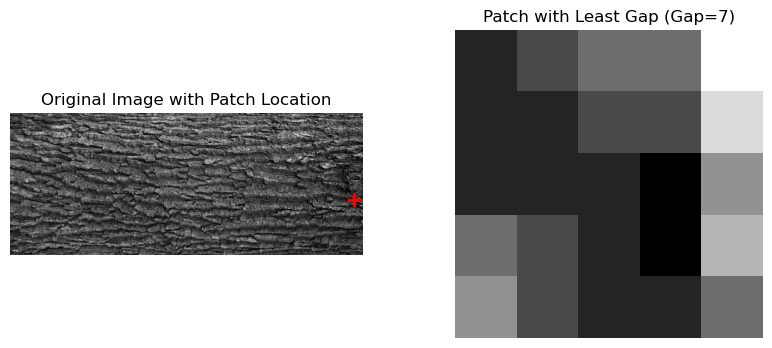

In [ ]:
def find_patch_with_least_gap(image, patch_size=5, step_size=10):
    h, w = image.shape
    half = patch_size // 2
    
    min_gap = float('inf')
    best_patch = None
    best_position = None
    best_range = None
    
    for y in range(half, h - half, step_size):
        for x in range(half, w - half, step_size):
            current_patch = patch(image, y, x, patch_size)

            min_val = current_patch.min()
            max_val = current_patch.max()
            gap = max_val - min_val

            if gap < min_gap:
                min_gap = gap
                best_patch = current_patch.copy()
                best_position = (y, x)
                best_range = (min_val, max_val)
    
    return best_patch, best_position, min_gap, best_range

least_gap_patch, position, gap, (min_val, max_val) = find_patch_with_least_gap(img)

print(f"Patch with least gap found at position (y={position[0]}, x={position[1]})")
print(f"Gap (range): {gap}")
print(f"Min value: {min_val}, Max value: {max_val}")
print(f"Patch:\n{least_gap_patch}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.plot(position[1], position[0], 'r+', markersize=10, markeredgewidth=2)
plt.title('Original Image with Patch Location')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(least_gap_patch, cmap='gray')
plt.title(f'Patch with Least Gap (Gap={gap})')
plt.axis('off')
plt.show()  

In [112]:
def glcm_y(image, L):
    glcm = np.zeros((L, L), dtype=int)
    h, w = image.shape
    for y in range(h - 1): 
        for x in range(w):
            i = image[y, x]
            j = image[y + 1, x]
            glcm[i, j] += 1       
    return glcm

def glcm_x(image, L):
    glcm = np.zeros((L, L), dtype=int)
    h, w = image.shape
    for y in range(h): 
        for x in range(w - 1):
            i = image[y, x]
            j = image[y, x + 1]
            glcm[i, j] += 1      
    return glcm

def glcm_xy(image, L):
    glcm = np.zeros((L, L), dtype=int)
    h, w = image.shape
    for y in range(h - 1): 
        for x in range(w - 1):
            i = image[y, x]
            j = image[y + 1, x + 1]
            glcm[i, j] += 1       
    return glcm

In [113]:
def maxm_probability(glcm):
    p= glcm / glcm.sum()
    return np.max(p)

def energy(glcm):
    sum= glcm / glcm.sum()
    return np.sum(sum ** 2)

def entropy(glcm):
    prob= glcm / glcm.sum()
    sum = 0.0
    for y in range(prob.shape[0]):
        for x in range(prob.shape[1]):
            if prob[y, x] > 0:
                sum += prob[y, x] * np.log2(prob[y, x])
    return -sum

def contrast(glcm):
    h,w=glcm.shape
    prob= glcm / glcm.sum()
    total=0.0
    for y in range(h):
        for x in range(w):
            total=((y-x)**2)*prob[y,x]
    return total

def homogenity(glcm):
    h,w=glcm.shape
    prob= glcm / glcm.sum()
    total=0.0
    for y in range(h):
        for x in range(w):
            total=(prob[y,x])/(1+np.abs(y-x))
    return total

In [114]:
glcm1_x = glcm_x(qpatch, new_lvls)
glcm1_y = glcm_y(qpatch, new_lvls)
glcm1_xy = glcm_xy(qpatch, new_lvls)

print("GLCM X:\n", glcm1_x)
print("GLCM Y:\n", glcm1_y)
print("GLCM XY:\n", glcm1_xy)

GLCM X:
 [[0 0 0 0 1 1 0 0]
 [2 4 2 1 0 0 0 0]
 [0 2 1 1 0 0 1 0]
 [0 0 1 1 0 0 0 1]
 [0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]
GLCM Y:
 [[1 1 0 0 0 0 0 0]
 [0 5 1 1 0 0 0 0]
 [1 2 1 0 0 0 0 0]
 [0 0 2 0 1 0 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 1 0]]
GLCM XY:
 [[0 0 0 1 0 1 0 0]
 [1 5 1 0 0 0 0 0]
 [1 1 1 0 1 0 0 0]
 [0 0 2 0 0 0 1 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]


In [115]:
def print_glcm_features(image, glcm, direction):
    print(f"GLCM Features for {direction} direction:")
    print(f"Maximal Probability: {maxm_probability(glcm)}")
    print(f"Energy: {energy(glcm)}")
    print(f"Entropy: {entropy(glcm)}")
    print(f"Contrast: {contrast(glcm)}")
    print(f"Homogeneity: {homogenity(glcm)}")
    print("\n")
    
print_glcm_features(img_patch, glcm1_x, "Horizontal")
print_glcm_features(img_patch, glcm1_y, "Vertical")
print_glcm_features(img_patch, glcm1_xy, "Diagonal")

GLCM Features for Horizontal direction:
Maximal Probability: 0.2
Energy: 0.09500000000000003
Entropy: 3.621928094887362
Contrast: 0.0
Homogeneity: 0.0


GLCM Features for Vertical direction:
Maximal Probability: 0.25
Energy: 0.11000000000000001
Entropy: 3.5414460711655216
Contrast: 0.0
Homogeneity: 0.0


GLCM Features for Diagonal direction:
Maximal Probability: 0.3125
Energy: 0.1484375
Entropy: 3.149397470347699
Contrast: 0.0
Homogeneity: 0.0


